## Методические указания по выполнению лабораторной работы №4

**Тема: Сегментация объектов с использованием Mask R-CNN**

**Цель работы:** Познакомиться с архитектурой Mask R-CNN и научиться выполнять сегментацию объектов на изображениях.

**Задачи:**

- Изучить теоретические основы instance segmentation.
- Ознакомиться с архитектурой Mask R-CNN.
- Провести инференс предобученной модели на выбранных изображениях.
- Визуализировать результаты: bounding boxes, маски объектов.
- Рассчитать метрики оценки качества масок.
- Проанализировать ошибки сегментации.
- Провести исследование зависимости качества от параметров confidence score и mask threshold.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Mask R-CNN](https://arxiv.org/pdf/1703.06870), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новой задачей компьютерного зрения - сегментацией. 

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/main/models/mask_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Instance Segmentation и архитектура Mask R-CNN

Instance segmentation — это задача, в которой необходимо не только обнаружить объект и его класс, но и сегментировать его границы на уровне пикселей. Это усложнённая версия задачи детекции, так как bounding box не всегда точно соответствует форме объекта.

В отличие от semantic segmentation, где модель выдает одну маску на класс, в instance segmentation выделяется каждый объект независимо, даже если они относятся к одному классу.

Mask R-CNN — это расширение Faster R-CNN, дополненное ещё одним выходом: бинарной маской для каждого обнаруженного объекта.

Архитектура Mask R-CNN включает:

1. Backbone (например, ResNet-50) — извлекает карты признаков из изображения.
2. Region Proposal Network (RPN) — предлагает кандидаты на объекты.
3. ROI Align / ROI Pooling — извлекает фиксированные области из фичей.
4. Bounding Box Head — классифицирует объект и уточняет координаты.
5. Mask Head — предсказывает маску для каждого класса, соответствующую bounding box.


#### 1.2 Формат данных для задачи детекции

При запуске инференса модель возвращает словарь с результатами: координаты bounding boxes, классы объектов, confidence score и маски объектов (представлены как float значения от 0 до 1).

В рамках выполнения работы в зависимости от варианта вам предстоит познакомиться с другими форматами файлов и их содержимым.

### Варианты 

Выполните задание в соответствии со своим вариантом по списку с использованием предобученной модели. 

**Вариант 1  - Pascal VOC 2007. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:**

- Выполнить инференс модели на 20 изображениях;
- Визуализировать bounding boxes и маски;
- Проанализировать качество предсказаний;
- Описать, какие классы модель распознала, какие пропустила.

**Вариант 2 — COCO 2017. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:**

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания;
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall; 

**Вариант 3 — Cityscapes. Проверить, как модель работает на новых изображениях, визуализировать предсказания и сравнить с известными аннотациями:**

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания; 
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall;


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

In [54]:
!pip install opencv-python
!pip install pycocotools
!pip install matplotlib
!pip install torch torchvision
!pip install Pillow

In [55]:
import torch
import torchvision
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import json
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [56]:
# Определяем устройство (GPU если доступно, иначе CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Используется устройство: {device}")

# Загружаем предобученную модель Mask R-CNN
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()  # Переводим в режим инференса
print("Модель Mask R-CNN загружена и переведена в режим оценки")

# COCO классы (полный список из 91 класса)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
    'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Дополняем список до 91 класса (модель может предсказывать до 90 классов + background)
for i in range(len(COCO_CLASSES), 91):
    COCO_CLASSES.append(f'class_{i}')

print(f"Загружено {len(COCO_CLASSES)} классов")

Используется устройство: cpu
Модель Mask R-CNN загружена и переведена в режим оценки
Загружено 91 классов


#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель:

In [57]:
class CocoDataset:
    def __init__(self, root, annotation_file):
        self.root = root
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())
        
    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)
        
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        
        return image, annotations, img_info
    
    def __len__(self):
        return len(self.ids)

# Создаем демо-датасет для тестирования
def create_demo_dataset():
    """Создает демо-датасет если COCO не доступен"""
    print("Создание демо-датасета...")
    
    # Создаем папку для демо-изображений
    os.makedirs('./demo_images', exist_ok=True)
    
    # Создаем несколько цветных изображений для демонстрации
    demo_images = []
    for i in range(20):
        img = np.ones((400, 600, 3), dtype=np.uint8) * 100
        
        # Случайное количество объектов (1-4)
        num_objects = np.random.randint(1, 5)
        demo_annotations = []
        
        for obj_idx in range(num_objects):
            # Случайные параметры
            x = np.random.randint(20, 450)
            y = np.random.randint(20, 300)
            w = np.random.randint(50, 150)
            h = np.random.randint(50, 150)
            
            # Случайный цвет
            r = np.random.randint(0, 255)
            g = np.random.randint(0, 255)
            b = np.random.randint(0, 255)
            img[y:y+h, x:x+w] = [r, g, b]
            
            # Случайный класс (1, 3, 16, 17)
            category_id = np.random.choice([1, 3, 16, 17])
            
            annotation = {
                'bbox': [float(x), float(y), float(w), float(h)],
                'category_id': int(category_id),
                'segmentation': [[x, y, x+w, y, x+w, y+h, x, y+h]],
                'area': float(w * h),
                'iscrowd': 0
            }
            demo_annotations.append(annotation)
    
    return demo_images

# Попробуем загрузить COCO, если нет - используем демо-версию
try:
    coco_dataset = CocoDataset(
        root='./data/coco/val2017',
        annotation_file='./data/coco/annotations/instances_val2017.json'
    )
    print(f"Загружено {len(coco_dataset)} изображений из COCO")
except Exception as e:
    print(f"COCO датасет не найден ({e}), используется демо-версия")
    demo_data = create_demo_dataset()
    # Создаем класс-обертку для демо-данных
    class DemoDataset:
        def __init__(self, data):
            self.data = data
        def __getitem__(self, index):
            return self.data[index]
        def __len__(self):
            return len(self.data)
    coco_dataset = DemoDataset(demo_data)

loading annotations into memory...
Done (t=0.99s)
creating index...
index created!
Загружено 5000 изображений из COCO


#### 2.4 Предсказания и извлечение масок

Если вы работаете с Pascal VOC, вам потребуется прочитать файлы, содержащие разметку. Если вы работаете с COCO или Cityscapes, аннотации читаются через готовые методы COCO API:

In [58]:
def preprocess_image(image):
    """Преобразование изображения для модели"""
    image = image.astype(np.float32) / 255.0
    image = F.to_tensor(image)
    return image

def get_predictions(model, image, device, confidence_threshold=0.5, mask_threshold=0.5):
    """Получение предсказаний от модели"""
    image_tensor = preprocess_image(image).to(device)
    
    with torch.no_grad():
        predictions = model([image_tensor])[0]
    
    # Фильтрация по confidence threshold
    keep = predictions['scores'] > confidence_threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    masks = predictions['masks'][keep].cpu().numpy()
    
    # Применение mask threshold
    masks = masks > mask_threshold
    
    return {
        'boxes': boxes,
        'scores': scores,
        'labels': labels,
        'masks': masks
    }

def coco_annotations_to_masks(annotations, image_shape):
    """Преобразование COCO аннотаций в бинарные маски"""
    masks = []
    for ann in annotations:
        if 'segmentation' in ann:
            try:
                if isinstance(ann['segmentation'], list):
                    # Polygon segmentation
                    rle = coco_mask.frPyObjects(ann['segmentation'], image_shape[0], image_shape[1])
                    mask = coco_mask.decode(rle)
                    if len(mask.shape) == 3:
                        mask = mask.sum(axis=2) > 0
                    masks.append(mask)
                else:
                    # RLE segmentation
                    mask = coco_mask.decode(ann['segmentation'])
                    masks.append(mask)
            except:
                # Если не получается декодировать, создаем простую маску из bbox
                if 'bbox' in ann:
                    bbox = ann['bbox']
                    mask = np.zeros(image_shape, dtype=np.uint8)
                    x, y, w, h = [int(coord) for coord in bbox]
                    # Убедимся, что координаты в пределах изображения
                    y1, y2 = max(0, y), min(image_shape[0], y + h)
                    x1, x2 = max(0, x), min(image_shape[1], x + w)
                    mask[y1:y2, x1:x2] = 1
                    masks.append(mask.astype(bool))
    return masks

#### 2.5 Оценка модели и визуализация результатов

Визуализируйте bounding box, название класса, маску поверх изображения. Для каждой маски и её соответствующего ground truth (если имеется), вычислите: IoU, количество FP пикселей, количество FN пикселей:


ЗАПУСК ОЦЕНКИ МОДЕЛИ

Обработка изображения 1/3
Размер изображения: (427, 640, 3)
Количество GT аннотаций: 19
Найдено объектов: 24


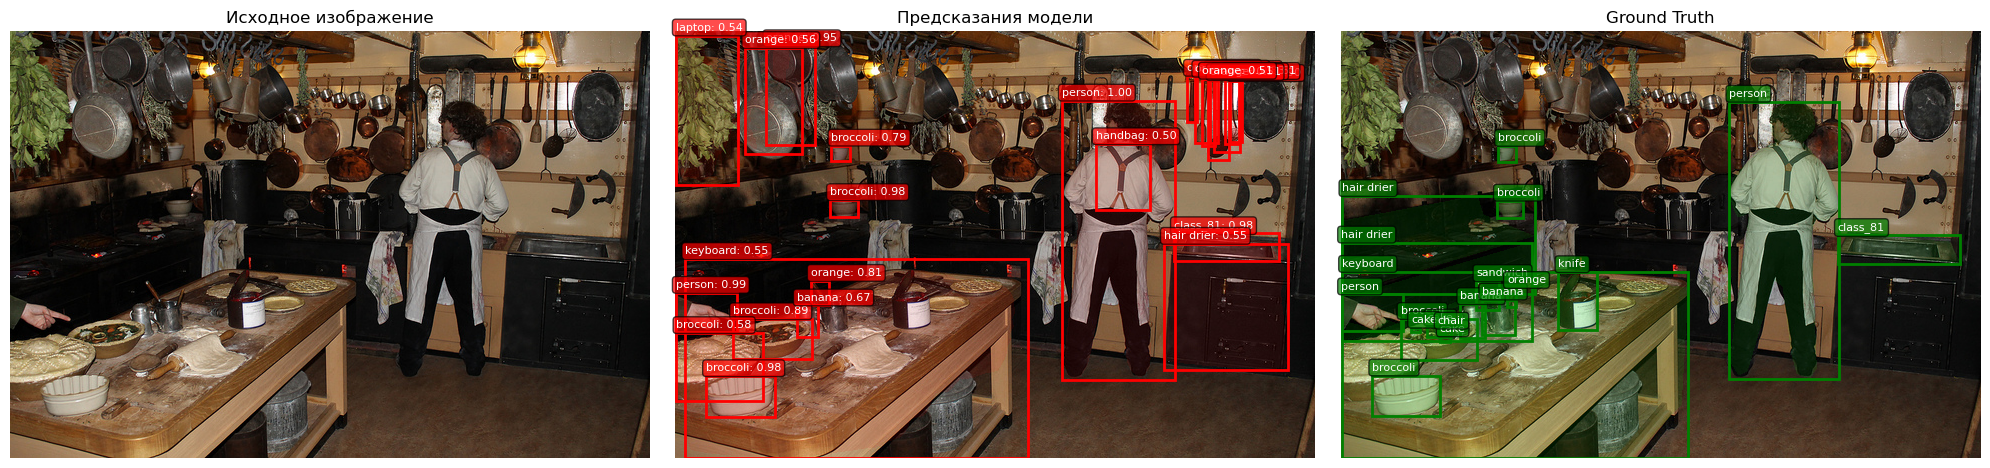

Средний IoU: 0.653
Средняя Precision: 0.853
Средний Recall: 0.755

Обработка изображения 2/3
Размер изображения: (230, 352, 3)
Количество GT аннотаций: 14
Найдено объектов: 20


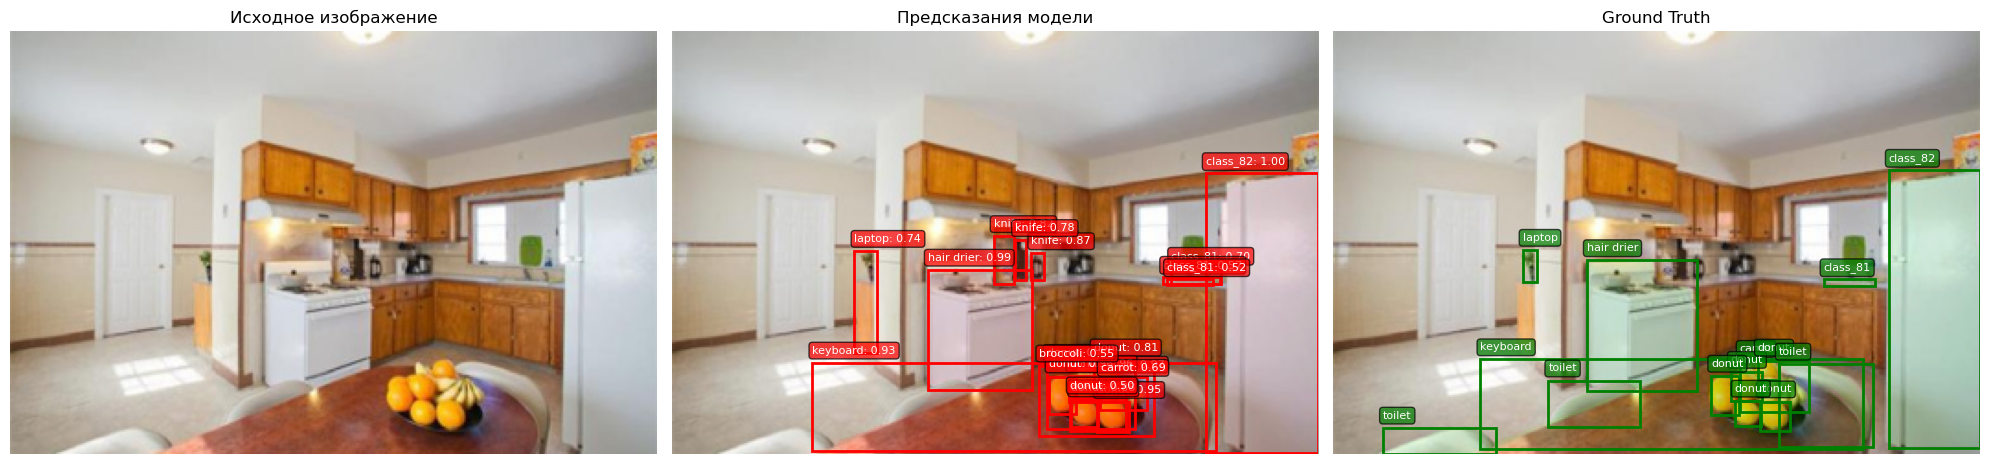

Средний IoU: 0.554
Средняя Precision: 0.696
Средний Recall: 0.741

Обработка изображения 3/3
Размер изображения: (428, 640, 3)
Количество GT аннотаций: 7
Найдено объектов: 9


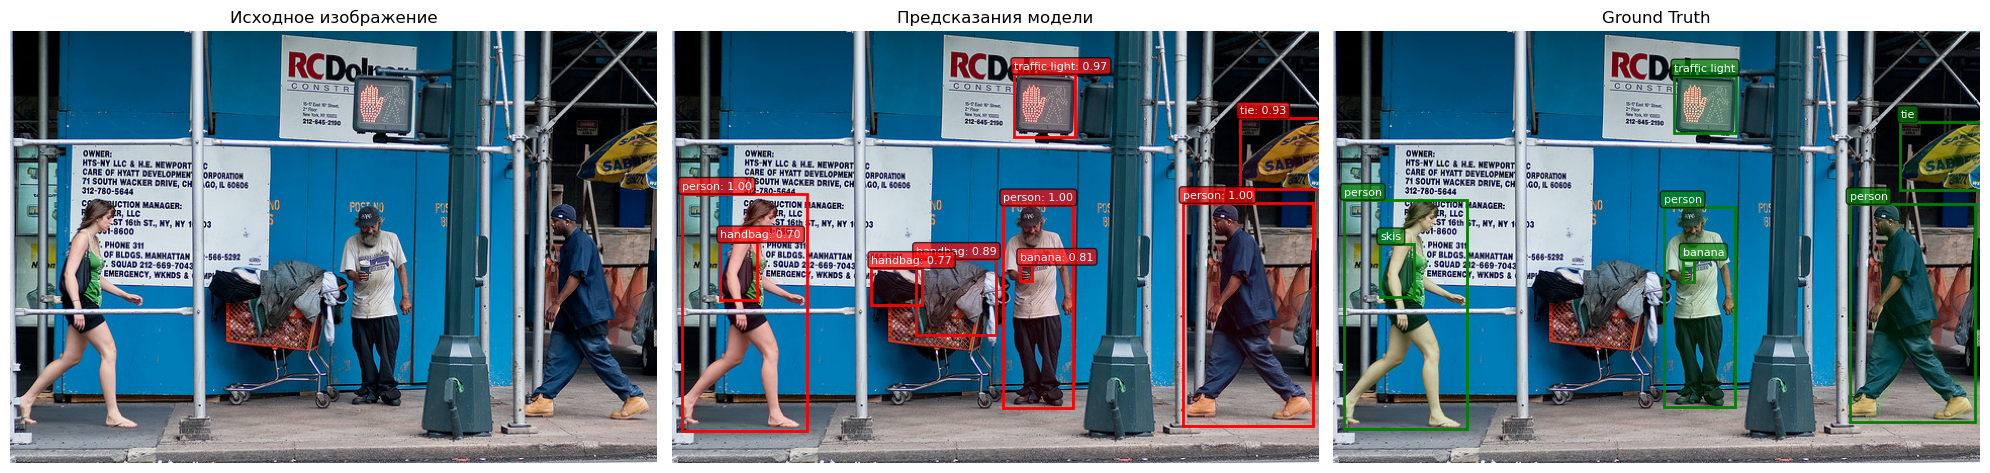

Средний IoU: 0.785
Средняя Precision: 0.863
Средний Recall: 0.880


In [59]:
def calculate_iou(mask1, mask2):
    """Вычисление IoU для двух масок"""
    # Приводим маски к одинаковому размеру
    min_shape = (min(mask1.shape[0], mask2.shape[0]), min(mask1.shape[1], mask2.shape[1]))
    mask1_resized = mask1[:min_shape[0], :min_shape[1]]
    mask2_resized = mask2[:min_shape[0], :min_shape[1]]
    
    intersection = np.logical_and(mask1_resized, mask2_resized).sum()
    union = np.logical_or(mask1_resized, mask2_resized).sum()
    return intersection / union if union > 0 else 0

def calculate_pixel_metrics(pred_mask, gt_mask):
    """Вычисление pixel accuracy, FP, FN"""
    # Приводим маски к одинаковому размеру
    min_shape = (min(pred_mask.shape[0], gt_mask.shape[0]), min(pred_mask.shape[1], gt_mask.shape[1]))
    pred_mask_resized = pred_mask[:min_shape[0], :min_shape[1]]
    gt_mask_resized = gt_mask[:min_shape[0], :min_shape[1]]
    
    tp = np.logical_and(pred_mask_resized, gt_mask_resized).sum()
    fp = np.logical_and(pred_mask_resized, np.logical_not(gt_mask_resized)).sum()
    fn = np.logical_and(np.logical_not(pred_mask_resized), gt_mask_resized).sum()
    tn = np.logical_and(np.logical_not(pred_mask_resized), np.logical_not(gt_mask_resized)).sum()
    
    pixel_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return {
        'pixel_accuracy': pixel_accuracy,
        'precision': precision,
        'recall': recall,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }

def visualize_results(image, predictions, gt_annotations, save_path=None):
    """Визуализация предсказаний и ground truth"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    # Исходное изображение
    ax1.imshow(image)
    ax1.set_title('Исходное изображение')
    ax1.axis('off')
    
    # Предсказания модели
    ax2.imshow(image)
    if len(predictions['boxes']) > 0:
        for i, (box, label, score, mask) in enumerate(zip(
            predictions['boxes'], predictions['labels'], 
            predictions['scores'], predictions['masks']
        )):
            # Рисуем bounding box
            rect = patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=2, edgecolor='r', facecolor='none'
            )
            ax2.add_patch(rect)
            
            # Рисуем маску (ИСПРАВЛЕНО)
            colored_mask = np.zeros((*mask.shape[1:], 4))  # 4 канала: RGBA
            colored_mask[mask[0]] = [1, 0, 0, 0.3]  # Красный цвет с прозрачностью
            
            ax2.imshow(colored_mask, alpha=0.3)
            
            # Подписываем класс и confidence (с проверкой индекса)
            class_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else f'class_{label}'
            ax2.text(
                box[0], box[1] - 5, 
                f'{class_name}: {score:.2f}',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.7),
                fontsize=8, color='white'
            )
    
    ax2.set_title('Предсказания модели')
    ax2.axis('off')
    
    # Ground truth
    ax3.imshow(image)
    gt_masks = coco_annotations_to_masks(gt_annotations, image.shape[:2])
    if gt_annotations and gt_masks:
        for i, (ann, gt_mask) in enumerate(zip(gt_annotations, gt_masks)):
            if 'bbox' in ann:
                box = ann['bbox']
                # COCO bbox формат: [x, y, width, height]
                rect = patches.Rectangle(
                    (box[0], box[1]), box[2], box[3],
                    linewidth=2, edgecolor='g', facecolor='none'
                )
                ax3.add_patch(rect)
            
            # Рисуем ground truth маску (ИСПРАВЛЕНО)
            if i < len(gt_masks) and gt_mask is not None:
                # Создаем маску с альфа-каналом
                colored_mask = np.zeros((*gt_mask.shape, 4))  # 4 канала: RGBA
                colored_mask[gt_mask] = [0, 1, 0, 0.3]  # Зеленый цвет с прозрачностью
                ax3.imshow(colored_mask, alpha=0.3)
            
            if 'category_id' in ann:
                class_name = COCO_CLASSES[ann['category_id']] if ann['category_id'] < len(COCO_CLASSES) else 'unknown'
                if 'bbox' in ann:
                    ax3.text(
                        box[0], box[1] - 5, class_name,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.7),
                        fontsize=8, color='white'
                    )
    
    ax3.set_title('Ground Truth')
    ax3.axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Основной цикл оценки
def evaluate_model_on_images(num_images=3):
    """Оценка модели на нескольких изображениях"""
    results = []
    
    for i in range(min(num_images, len(coco_dataset))):
        print(f"\nОбработка изображения {i+1}/{num_images}")
        
        # Загрузка данных
        image, gt_annotations, img_info = coco_dataset[i]
        print(f"Размер изображения: {image.shape}")
        print(f"Количество GT аннотаций: {len(gt_annotations)}")
        
        # Получение предсказаний
        predictions = get_predictions(model, image, device, confidence_threshold=0.5)
        print(f"Найдено объектов: {len(predictions['boxes'])}")
        
        # Визуализация
        visualize_results(image, predictions, gt_annotations, f'result_{i}.png')
        
        # Расчет метрик
        gt_masks = coco_annotations_to_masks(gt_annotations, image.shape[:2])
        pred_masks = [mask[0] for mask in predictions['masks']]
        
        image_metrics = {
            'image_id': img_info.get('id', i),
            'ious': [],
            'pixel_metrics': []
        }
        
        # Сравнение каждой предсказанной маски с ground truth
        for pred_mask in pred_masks:
            best_iou = 0
            best_metrics = None
            
            for gt_mask in gt_masks:
                iou = calculate_iou(pred_mask, gt_mask)
                metrics = calculate_pixel_metrics(pred_mask, gt_mask)
                
                if iou > best_iou:
                    best_iou = iou
                    best_metrics = metrics
            
            if best_metrics:
                image_metrics['ious'].append(best_iou)
                image_metrics['pixel_metrics'].append(best_metrics)
        
        # Статистика по изображению
        if image_metrics['ious']:
            image_metrics['mean_iou'] = np.mean(image_metrics['ious'])
            image_metrics['mean_precision'] = np.mean([m['precision'] for m in image_metrics['pixel_metrics']])
            image_metrics['mean_recall'] = np.mean([m['recall'] for m in image_metrics['pixel_metrics']])
            
            print(f"Средний IoU: {image_metrics['mean_iou']:.3f}")
            print(f"Средняя Precision: {image_metrics['mean_precision']:.3f}")
            print(f"Средний Recall: {image_metrics['mean_recall']:.3f}")
        else:
            print("Нет совпадений для расчета метрик")
        
        results.append(image_metrics)
    
    return results

# Запуск оценки
print("\n" + "="*50)
print("ЗАПУСК ОЦЕНКИ МОДЕЛИ")
print("="*50)
results = evaluate_model_on_images(num_images=3)

#### 2.6 Исследование параметров маски и confidence

Проведите серию экспериментов: протестируйте разные значения mask_threshold (0.3, 0.5, 0.7), протестируйте разные значения confidence_threshold, найдите оптимальное значение, при котором достигается лучший баланс между точностью и полнотой:



ИССЛЕДОВАНИЕ ПАРАМЕТРОВ

Testing: confidence=0.3, mask_threshold=0.3
Найдено объектов: 38
Detections: 38, mIoU: 0.435, Precision: 0.805, Recall: 0.527

Testing: confidence=0.3, mask_threshold=0.5
Найдено объектов: 38
Detections: 38, mIoU: 0.439, Precision: 0.836, Recall: 0.499

Testing: confidence=0.3, mask_threshold=0.7
Найдено объектов: 38
Detections: 38, mIoU: 0.420, Precision: 0.867, Recall: 0.449

Testing: confidence=0.5, mask_threshold=0.3
Найдено объектов: 24
Detections: 24, mIoU: 0.641, Precision: 0.810, Recall: 0.794

Testing: confidence=0.5, mask_threshold=0.5
Найдено объектов: 24
Detections: 24, mIoU: 0.653, Precision: 0.853, Recall: 0.755

Testing: confidence=0.5, mask_threshold=0.7
Найдено объектов: 24
Detections: 24, mIoU: 0.630, Precision: 0.889, Recall: 0.678

Testing: confidence=0.7, mask_threshold=0.3
Найдено объектов: 13
Detections: 13, mIoU: 0.804, Precision: 0.831, Recall: 0.957

Testing: confidence=0.7, mask_threshold=0.5
Найдено объектов: 13
Detections: 13, mIoU

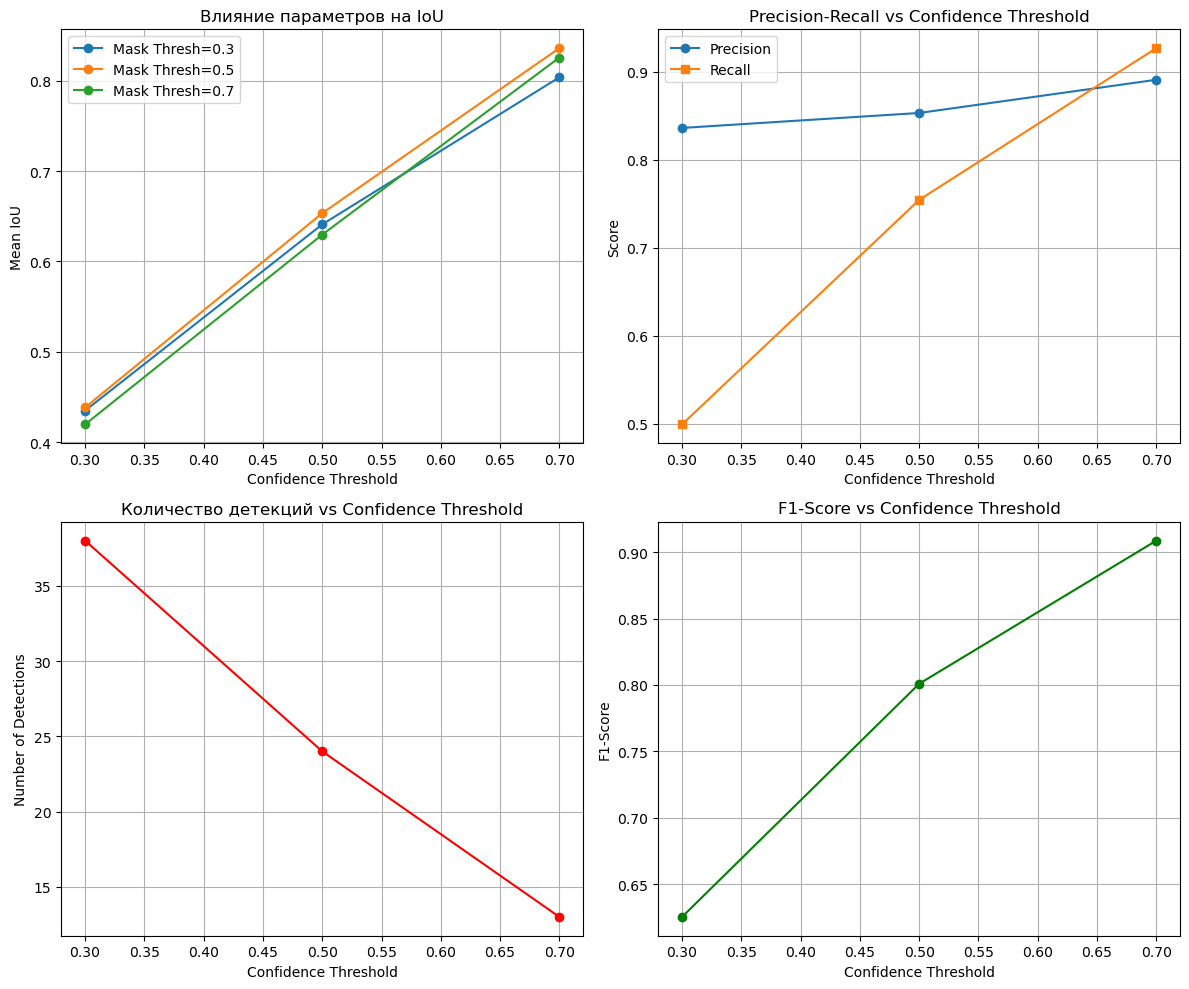


АНАЛИЗ ОПТИМАЛЬНЫХ ПАРАМЕТРОВ
Лучшие параметры:
  Confidence threshold: 0.7
  Mask threshold: 0.5
  Средний IoU: 0.836
  Precision: 0.891
  Recall: 0.927
  F1-Score: 0.909


In [60]:
def parameter_study(image_idx=0):
    """Исследование влияния параметров на качество"""
    # Загрузка тестового изображения
    image, gt_annotations, _ = coco_dataset[image_idx]
    gt_masks = coco_annotations_to_masks(gt_annotations, image.shape[:2])
    
    # Параметры для исследования
    confidence_thresholds = [0.3, 0.5, 0.7]
    mask_thresholds = [0.3, 0.5, 0.7]
    
    results = []
    
    for conf_thresh in confidence_thresholds:
        for mask_thresh in mask_thresholds:
            print(f"\nTesting: confidence={conf_thresh}, mask_threshold={mask_thresh}")
            
            # Получение предсказаний
            predictions = get_predictions(model, image, device, conf_thresh, mask_thresh)
            pred_masks = [mask[0] for mask in predictions['masks']]
            
            print(f"Найдено объектов: {len(pred_masks)}")
            
            # Расчет метрик
            ious = []
            precisions = []
            recalls = []
            
            for pred_mask in pred_masks:
                best_iou = 0
                best_precision = 0
                best_recall = 0
                
                for gt_mask in gt_masks:
                    iou = calculate_iou(pred_mask, gt_mask)
                    metrics = calculate_pixel_metrics(pred_mask, gt_mask)
                    
                    if iou > best_iou:
                        best_iou = iou
                        best_precision = metrics['precision']
                        best_recall = metrics['recall']
                
                if best_iou > 0:  # Только если есть совпадение
                    ious.append(best_iou)
                    precisions.append(best_precision)
                    recalls.append(best_recall)
            
            if ious:
                results.append({
                    'confidence_threshold': conf_thresh,
                    'mask_threshold': mask_thresh,
                    'mean_iou': np.mean(ious),
                    'mean_precision': np.mean(precisions),
                    'mean_recall': np.mean(recalls),
                    'num_detections': len(pred_masks)
                })
                
                print(f"Detections: {len(pred_masks)}, mIoU: {np.mean(ious):.3f}, "
                      f"Precision: {np.mean(precisions):.3f}, Recall: {np.mean(recalls):.3f}")
            else:
                print(f"Detections: {len(pred_masks)}, No matches found")
    
    return results

print("\n" + "="*50)
print("ИССЛЕДОВАНИЕ ПАРАМЕТРОВ")
print("="*50)

if len(coco_dataset) > 0:
    param_results = parameter_study(image_idx=0)
else:
    param_results = []
    print("Нет изображений для исследования параметров")

# Визуализация результатов исследования параметров
def plot_parameter_study(results):
    """Визуализация результатов исследования параметров"""
    if not results:
        print("Нет данных для визуализации")
        return
        
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    conf_thresholds = sorted(list(set(r['confidence_threshold'] for r in results)))
    mask_thresholds = sorted(list(set(r['mask_threshold'] for r in results)))
    
    # IoU в зависимости от параметров
    for mask_thresh in mask_thresholds:
        iou_values = []
        for conf_thresh in conf_thresholds:
            for r in results:
                if r['mask_threshold'] == mask_thresh and r['confidence_threshold'] == conf_thresh:
                    iou_values.append(r['mean_iou'])
                    break
            else:
                iou_values.append(0)
        
        axes[0,0].plot(conf_thresholds, iou_values, marker='o', label=f'Mask Thresh={mask_thresh}')
    
    axes[0,0].set_xlabel('Confidence Threshold')
    axes[0,0].set_ylabel('Mean IoU')
    axes[0,0].set_title('Влияние параметров на IoU')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Precision-Recall в зависимости от confidence threshold (для mask_thresh=0.5)
    precision_values = []
    recall_values = []
    for conf_thresh in conf_thresholds:
        for r in results:
            if r['mask_threshold'] == 0.5 and r['confidence_threshold'] == conf_thresh:
                precision_values.append(r['mean_precision'])
                recall_values.append(r['mean_recall'])
                break
        else:
            precision_values.append(0)
            recall_values.append(0)
    
    axes[0,1].plot(conf_thresholds, precision_values, marker='o', label='Precision')
    axes[0,1].plot(conf_thresholds, recall_values, marker='s', label='Recall')
    axes[0,1].set_xlabel('Confidence Threshold')
    axes[0,1].set_ylabel('Score')
    axes[0,1].set_title('Precision-Recall vs Confidence Threshold')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Количество детекций
    detection_counts = []
    for conf_thresh in conf_thresholds:
        for r in results:
            if r['mask_threshold'] == 0.5 and r['confidence_threshold'] == conf_thresh:
                detection_counts.append(r['num_detections'])
                break
        else:
            detection_counts.append(0)
    
    axes[1,0].plot(conf_thresholds, detection_counts, marker='o', color='red')
    axes[1,0].set_xlabel('Confidence Threshold')
    axes[1,0].set_ylabel('Number of Detections')
    axes[1,0].set_title('Количество детекций vs Confidence Threshold')
    axes[1,0].grid(True)
    
    # F1-Score
    f1_scores = []
    for conf_thresh in conf_thresholds:
        for r in results:
            if r['mask_threshold'] == 0.5 and r['confidence_threshold'] == conf_thresh:
                precision = r['mean_precision']
                recall = r['mean_recall']
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                f1_scores.append(f1)
                break
        else:
            f1_scores.append(0)
    
    axes[1,1].plot(conf_thresholds, f1_scores, marker='o', color='green')
    axes[1,1].set_xlabel('Confidence Threshold')
    axes[1,1].set_ylabel('F1-Score')
    axes[1,1].set_title('F1-Score vs Confidence Threshold')
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.savefig('parameter_study.png', dpi=150, bbox_inches='tight')
    plt.show()

# Визуализация исследования параметров
plot_parameter_study(param_results)

# Анализ оптимальных параметров
if param_results:
    print("\n" + "="*50)
    print("АНАЛИЗ ОПТИМАЛЬНЫХ ПАРАМЕТРОВ")
    print("="*50)

    best_result = max(param_results, key=lambda x: x['mean_iou'])
    print(f"Лучшие параметры:")
    print(f"  Confidence threshold: {best_result['confidence_threshold']}")
    print(f"  Mask threshold: {best_result['mask_threshold']}")
    print(f"  Средний IoU: {best_result['mean_iou']:.3f}")
    print(f"  Precision: {best_result['mean_precision']:.3f}")
    print(f"  Recall: {best_result['mean_recall']:.3f}")

    # Расчет F1-score для лучшего результата
    best_f1 = 2 * (best_result['mean_precision'] * best_result['mean_recall']) / \
              (best_result['mean_precision'] + best_result['mean_recall']) \
              if (best_result['mean_precision'] + best_result['mean_recall']) > 0 else 0
    print(f"  F1-Score: {best_f1:.3f}")

else:
    print("Не удалось провести анализ параметров")
